In [2]:
import xarray as xr
import os   
import parflow as pf
import plotly.express as px
from parflow.tools.hydrology import calculate_overland_flow_grid, calculate_subsurface_storage, calculate_water_table_depth
import numpy as np
import shutil
import json
import plotly.io as pio
import matplotlib.pyplot as mpl

In [2]:
outlet_x = 66
outlet_y = 135

In [5]:
baseline = xr.open_dataset("/glade/derecho/scratch/bwest/drought-ensemble/domains/potomac_save/raw_runs/c6a8270c59d4b1edfca7b7ea99723a58e219f902b69b3d6b1fa8ba8db8b82387/processed_output.nc")

In [6]:
px.line(baseline.overland_flow.isel( x=outlet_x, y=outlet_y))

In [7]:
data = xr.open_dataset("/glade/derecho/scratch/bwest/drought-ensemble/domains/potomac_without_flow_barrier/raw_runs/c6a8270c59d4b1edfca7b7ea99723a58e219f902b69b3d6b1fa8ba8db8b82387/processed_output.nc")

In [8]:
data.info()

xarray.Dataset {
dimensions:
	time = 8760 ;
	z = 10 ;
	y = 136 ;
	x = 70 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(z, y, x) ;
	float64 mannings(y, x) ;
	float64 porosity(z, y, x) ;
	float64 specific_storage(z, y, x) ;
	float64 DZ_Multiplier(z, y, x) ;
	float64 slopex(y, x) ;
	float64 slopey(y, x) ;
	float64 perm_x(z, y, x) ;
	float64 perm_y(z, y, x) ;
	float64 perm_z(z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 subsurface_storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

In [9]:
px.line(data.overland_flow.isel( x=outlet_x, y=outlet_y))

In [4]:
root_dir = "/glade/derecho/scratch/bwest/drought-ensemble"
domain = "potomac_without_flow_barrier"
ensemble_name = "ensemble_1"
ensemble_member = "1_year_drought"
files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations.json"))
no_flow_barrier = xr.open_mfdataset(files, concat_dim="time", combine="nested")


/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/bwest/conda-envs/droughts/share/proj failed
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 

FileNotFoundError: [Errno 2] No such file or directory: '/glade/derecho/scratch/bwest/drought-ensemble/domains/potomac_without_flow_barrier/raw_runs/3d8ed65413d6f5858f7477507f81c0244343853678704237565653e027803569/processed_output.nc'

In [ ]:
root_dir = "/glade/derecho/scratch/bwest/drought-ensemble"
domain = "potomac_save"
ensemble_name = "ensemble_1"
ensemble_member = "1_year_drought"
files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations.json"))
flow_barrier = xr.open_mfdataset(files, concat_dim="time", combine="nested")


/glade/derecho/scratch/bwest/tmp/ipykernel_21344/341077437.py:6: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  flow_barrier = xr.open_mfdataset(files, concat_dim="time", combine="nested")


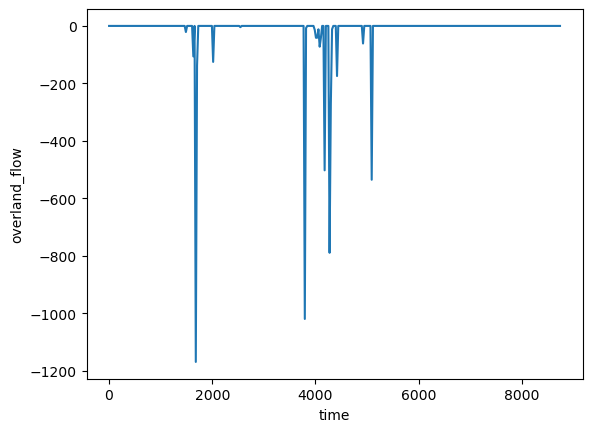

In [ ]:
start_time = 8760*8
end_time = 8760*9
streamflow_difference = no_flow_barrier.overland_flow.isel(time=slice(0, 8760,24), x=outlet_x, y=outlet_y) - flow_barrier.overland_flow.isel(time=slice(0, 8760,24), x=outlet_x, y=outlet_y)
streamflow_difference.plot()

In [ ]:
px.line(streamflow_difference)

NameError: name 'px' is not defined

In [4]:
xr.open_dataset("/glade/derecho/scratch/bwest/drought-ensemble/domains/potomac_without_flow_barrier/raw_runs/bc6c9e02a0acd5e6e97cd3ead4996d847fc26cffc90b391b839e489a2acffcf9/run.out.00001.nc")

<xarray.Dataset> Size: 21GB
Dimensions:           (time: 8760, z: 10, y: 136, x: 70)
Coordinates:
  * time              (time) float64 70kB 1.0 2.0 3.0 ... 8.759e+03 8.76e+03
Dimensions without coordinates: z, y, x
Data variables:
    pressure          (time, z, y, x) float64 7GB ...
    saturation        (time, z, y, x) float64 7GB ...
    evaptrans         (time, z, y, x) float64 7GB ...
    overland_bc_flux  (time, y, x) float64 667MB ...